# Dual-grid and PEC boundary validation with a rectangular cavity

This example validates two coupled boundary changes in `Wakis`:

1. the last dual-grid point is placed on the physical high-side boundary instead of duplicating the last cell center;
2. high-side PEC boundaries no longer remove the last stored interior tangential electric-field layer.

A rectangular vacuum cavity is excited by a short broadband `Ez` pulse. After the excitation, the cavity ringdown is recorded at an interior probe and transformed to the frequency domain.

Three configurations are compared:

- **Legacy**: former dual-grid construction + former PEC masking;
- **Dual-grid fix only**: corrected dual-grid construction + former PEC masking;
- **Full fix**: corrected dual-grid construction + corrected PEC masking.

The numerical resonances are compared with the analytical rectangular-cavity frequencies

$$
f_{mnp} =
\frac{c}{2}
\sqrt{
\left(\frac{m}{a}\right)^2 +
\left(\frac{n}{b}\right)^2 +
\left(\frac{p}{d}\right)^2
}.
$$

Because the excitation is `Ez`, the comparison focuses on TM modes. For the present cavity, the lowest TM mode is $\mathrm{TM}_{110}$, with \(p=0\), and it is the main quantitative reference in this example.


In [18]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.constants import c
from scipy.sparse import diags
from tqdm.auto import tqdm

from wakis.field import Field
from wakis.gridFIT3D import GridFIT3D
from wakis.solverFIT3D import SolverFIT3D
from wakis.sources import Pulse

## 1. Cavity, mesh and excitation

A non-cubic cavity is used to avoid unnecessary modal degeneracies. The mesh is deliberately rather coarse so that the effect of the boundary treatment is visible while the example remains inexpensive to run.



In [24]:
# Cavity dimensions [m]
a = 0.30
b = 0.25
d = 0.20

# Mesh cells
Nx = 18
Ny = 15
Nz = 12

dx = a / Nx
dy = b / Ny
dz = d / Nz

print(f"Cell sizes: dx={dx:.5f} m, dy={dy:.5f} m, dz={dz:.5f} m")

# Total simulated ringdown time.
# Increase this value for finer frequency resolution.
t_end = 100e-9

# Short broadband Harris pulse.
# Pulse.L is a spatial length because Pulse internally uses c*t.
pulse_length = 0.05  # [m]

# Non-symmetric source and probe positions help excite/observe several modes.
source_index = (
    int(0.37 * Nx),
    int(0.41 * Ny),
    int(0.43 * Nz),
)
probe_index = (
    int(0.63 * Nx),
    int(0.57 * Ny),
    int(0.61 * Nz),
)

print("Source index:", source_index)
print("Probe index :", probe_index)

Cell sizes: dx=0.01667 m, dy=0.01667 m, dz=0.01667 m
Source index: (6, 6, 5)
Probe index : (11, 8, 7)


## 2. Analytical TM resonances

For TM modes of a rectangular PEC cavity, $m,n \geq 1$ while $p$ may be zero. Therefore the fundamental TM resonance is $\mathrm{TM}_{110}$:

$$
f_{110} =
\frac{c}{2}
\sqrt{
\left(\frac{1}{a}\right)^2+
\left(\frac{1}{b}\right)^2
}.
$$

The small NumPy block below generates the analytical TM frequencies used as references in the spectrum plot.


In [25]:
# Analytical TM modes used as references
m, n, p = np.meshgrid(
    np.arange(1, 5),
    np.arange(1, 5),
    np.arange(0, 5),
    indexing="ij",
)

tm_indices = np.column_stack((m.ravel(), n.ravel(), p.ravel()))

tm_frequencies = (
    0.5
    * c
    * np.sqrt(
        (tm_indices[:, 0] / a) ** 2
        + (tm_indices[:, 1] / b) ** 2
        + (tm_indices[:, 2] / d) ** 2
    )
)

order = np.argsort(tm_frequencies)
tm_indices = tm_indices[order]
tm_frequencies = tm_frequencies[order]

f110 = 0.5 * c * np.sqrt((1.0 / a) ** 2 + (1.0 / b) ** 2)

print(f"Analytical TM110 frequency: {f110 / 1e9:.6f} GHz")
print("\nFirst analytical TM modes:")

for indices, frequency in zip(tm_indices[:8], tm_frequencies[:8]):
    m_i, n_i, p_i = indices
    print(f"TM{m_i}{n_i}{p_i}: {frequency / 1e9:.6f} GHz")

Analytical TM110 frequency: 0.780485 GHz

First analytical TM modes:
TM110: 0.780485 GHz
TM111: 1.082071 GHz
TM210: 1.165384 GHz
TM120: 1.299101 GHz
TM211: 1.385583 GHz
TM121: 1.499795 GHz
TM220: 1.560969 GHz
TM310: 1.614432 GHz


## 3. Validation-only legacy implementations

The two classes below exist only to reproduce the former behavior inside this example.

`LegacyPECSolver` restores the former high-side PEC masking, while `LegacyGridFIT3D` restores the former zero-length dual-grid boundary edges. Neither class is part of the Wakis API.


In [26]:
class LegacyPECSolver(SolverFIT3D):
    """Reproduce the former high-side PEC masking for validation only."""

    def _apply_bc_to_C(self):
        xlo = ylo = zlo = 1
        xhi = yhi = zhi = 1

        pec = {"electric", "pec", "pml", "cpml"}

        if self.bc_low[0].lower() in pec:
            xlo = 0
        if self.bc_low[1].lower() in pec:
            ylo = 0
        if self.bc_low[2].lower() in pec:
            zlo = 0

        if self.bc_high[0].lower() in pec:
            xhi = 0
        if self.bc_high[1].lower() in pec:
            yhi = 0
        if self.bc_high[2].lower() in pec:
            zhi = 0

        self.BC = Field(
            self.Nx,
            self.Ny,
            self.Nz,
            dtype=np.int8,
            use_ones=True,
        )

        for component in ["x", "y", "z"]:
            if component != "x":
                self.BC[0, :, :, component] = xlo
                self.BC[-1, :, :, component] = xhi

            if component != "y":
                self.BC[:, 0, :, component] = ylo
                self.BC[:, -1, :, component] = yhi

            if component != "z":
                self.BC[:, :, 0, component] = zlo
                self.BC[:, :, -1, component] = zhi

        self.Dbc = diags(
            self.BC.toarray(),
            shape=(3 * self.N, 3 * self.N),
            dtype=np.int8,
        )
        self.Dbc_x = diags(
            self.BC.field_x,
            shape=(self.N, self.N),
            dtype=np.int8,
        )
        self.Dbc_y = diags(
            self.BC.field_y,
            shape=(self.N, self.N),
            dtype=np.int8,
        )
        self.Dbc_z = diags(
            self.BC.field_z,
            shape=(self.N, self.N),
            dtype=np.int8,
        )

        self.C = self.C * self.Dbc


class LegacyGridFIT3D(GridFIT3D):
    """Reproduce the former high-side dual-grid treatment for validation only."""

    def _compute_grid(self):
        super()._compute_grid()

        self.tx = (self.x[1:] + self.x[:-1]) / 2
        self.ty = (self.y[1:] + self.y[:-1]) / 2
        self.tz = (self.z[1:] + self.z[:-1]) / 2

        self.tx = np.append(self.tx, self.tx[-1])
        self.ty = np.append(self.ty, self.ty[-1])
        self.tz = np.append(self.tz, self.tz[-1])

        tX, tY, tZ = np.meshgrid(
            self.tx,
            self.ty,
            self.tz,
            indexing="ij",
        )

        self.tL = Field(self.Nx, self.Ny, self.Nz)
        self.tL.field_x = tX[1:, 1:, 1:] - tX[:-1, :-1, :-1]
        self.tL.field_y = tY[1:, 1:, 1:] - tY[:-1, :-1, :-1]
        self.tL.field_z = tZ[1:, 1:, 1:] - tZ[:-1, :-1, :-1]

        self.itA = Field(self.Nx, self.Ny, self.Nz)

        aux = self.tL.field_y * self.tL.field_z
        self.itA.field_x = np.divide(
            1.0,
            aux,
            out=np.zeros_like(aux),
            where=aux != 0,
        )

        aux = self.tL.field_x * self.tL.field_z
        self.itA.field_y = np.divide(
            1.0,
            aux,
            out=np.zeros_like(aux),
            where=aux != 0,
        )

        aux = self.tL.field_x * self.tL.field_y
        self.itA.field_z = np.divide(
            1.0,
            aux,
            out=np.zeros_like(aux),
            where=aux != 0,
        )

## 4. Time-domain ringdown

The important simulation steps are kept directly in the example: create the Wakis grid, initialize `SolverFIT3D`, excite the cavity with `Pulse`, advance it with `one_step()`, and record the probe field.

The three cases differ only in the grid/solver classes used.


In [27]:
cases = [
    ("Legacy", LegacyGridFIT3D, LegacyPECSolver),
    ("Dual-grid fix only", GridFIT3D, LegacyPECSolver),
    ("Full fix", GridFIT3D, SolverFIT3D),
]

results = {}

for label, grid_class, solver_class in cases:
    print(f"\nRunning: {label}")

    grid = grid_class(
        xmin=0.0,
        xmax=a,
        ymin=0.0,
        ymax=b,
        zmin=0.0,
        zmax=d,
        Nx=Nx,
        Ny=Ny,
        Nz=Nz,
        verbose=0,
    )

    solver = solver_class(
        grid=grid,
        bc_low=["pec", "pec", "pec"],
        bc_high=["pec", "pec", "pec"],
        bg="vacuum",
        use_gpu=False,
        verbose=0,
    )

    source = Pulse(
        field="Ez",
        xs=source_index[0],
        ys=source_index[1],
        zs=source_index[2],
        shape="Harris",
        L=pulse_length,
        amplitude=1.0,
    )

    pulse_end = pulse_length / c
    Nt = int(np.ceil(t_end / solver.dt))

    signal = np.empty(Nt)

    for step in tqdm(range(Nt), desc=label):
        t = step * solver.dt

        # Apply the finite-duration source only while the pulse is active.
        if t <= pulse_end:
            source.update(solver, t)

        solver.one_step()

        signal[step] = solver.E[
            probe_index[0],
            probe_index[1],
            probe_index[2],
            "z",
        ]

    time = (np.arange(Nt) + 1) * solver.dt

    results[label] = {
        "solver": solver,
        "time": time,
        "signal": signal,
    }


Running: Legacy
Generating grid with 3240 mesh cells...
Initializing Electromagnetic solver...


Legacy:   0%|          | 0/6232 [00:00<?, ?it/s]


Running: Dual-grid fix only
Generating grid with 3240 mesh cells...
Initializing Electromagnetic solver...


Dual-grid fix only:   0%|          | 0/6232 [00:00<?, ?it/s]


Running: Full fix
Generating grid with 3240 mesh cells...
Initializing Electromagnetic solver...


Full fix:   0%|          | 0/6232 [00:00<?, ?it/s]

## 5. Cavity ringdown

Only the post-excitation part of the signals is used for the frequency-domain comparison below.


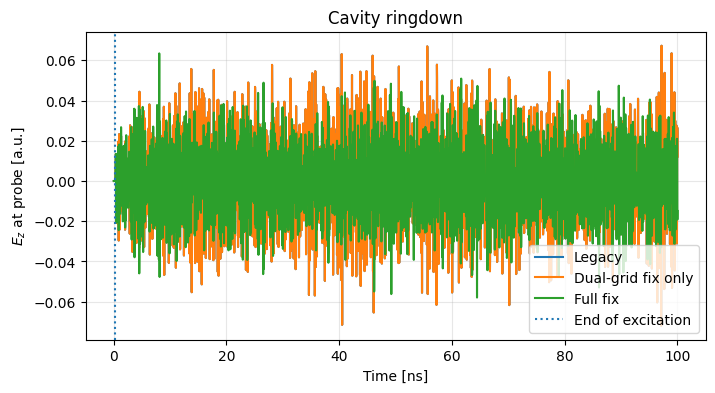

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, data in results.items():
    ax.plot(
        data["time"] * 1e9,
        data["signal"],
        label=label,
    )

ax.axvline(
    pulse_end * 1e9,
    linestyle=":",
    label="End of excitation",
)

ax.set_xlabel("Time [ns]")
ax.set_ylabel(r"$E_z$ at probe [a.u.]")
ax.set_title("Cavity ringdown")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

## 6. Resonance spectrum

A Hann window is applied to the free ringdown and the spectrum is computed with NumPy's real FFT.

The total ringdown time controls the frequency spacing,

\[
\Delta f \approx \frac{1}{T_\mathrm{ringdown}}.
\]


In [29]:
extra_delay = 0.5e-9

for label, data in results.items():
    time = data["time"]
    signal = data["signal"]

    start = np.searchsorted(
        time,
        pulse_end + extra_delay,
    )

    ringdown = signal[start:].copy()
    ringdown -= np.mean(ringdown)
    ringdown *= np.hanning(len(ringdown))

    dt = time[1] - time[0]
    frequency = np.fft.rfftfreq(
        len(ringdown),
        d=dt,
    )
    spectrum = np.abs(np.fft.rfft(ringdown))

    if spectrum.max() > 0:
        spectrum /= spectrum.max()

    data["frequency"] = frequency
    data["spectrum"] = spectrum

df = results["Full fix"]["frequency"][1] - results["Full fix"]["frequency"][0]
print(f"FFT frequency spacing: {df / 1e6:.3f} MHz")

FFT frequency spacing: 10.065 MHz


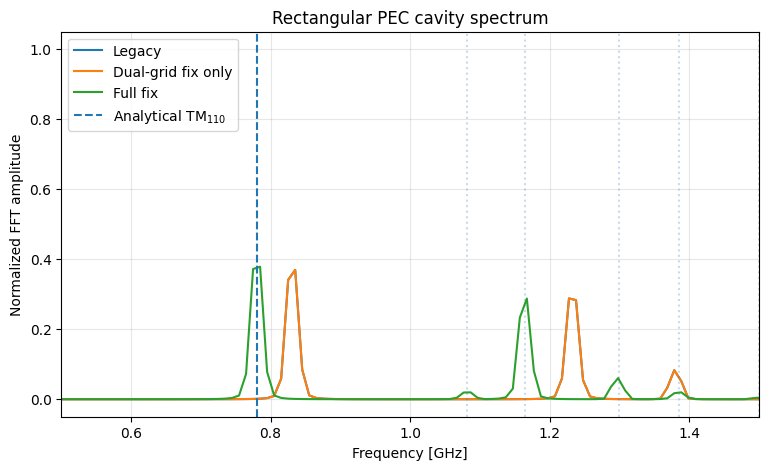

In [30]:
f_plot_min = 0.5e9
f_plot_max = 1.5e9

fig, ax = plt.subplots(figsize=(9, 5))

for label, data in results.items():
    ax.plot(
        data["frequency"] / 1e9,
        data["spectrum"],
        label=label,
    )

# Show analytical TM resonances in the plotted frequency range.
for frequency in tm_frequencies[
    (tm_frequencies >= f_plot_min) & (tm_frequencies <= f_plot_max)
]:
    ax.axvline(
        frequency / 1e9,
        linestyle=":",
        alpha=0.25,
    )

# Highlight the fundamental TM110 mode.
ax.axvline(
    f110 / 1e9,
    linestyle="--",
    linewidth=1.5,
    label=r"Analytical TM$_{110}$",
)

ax.set_xlim(
    f_plot_min / 1e9,
    f_plot_max / 1e9,
)
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Normalized FFT amplitude")
ax.set_title("Rectangular PEC cavity spectrum")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

## 7. Fundamental-mode comparison

The quantitative comparison is centered on the analytical $\mathrm{TM}_{110}$ resonance. For each case, the strongest FFT bin in a narrow frequency interval around $f_{110}$ is used as the numerical resonance estimate.


Analytical TM110: 0.780485 GHz

Legacy            : 0.835372 GHz (7.032 % error)
Dual-grid fix only: 0.835372 GHz (7.032 % error)
Full fix          : 0.785048 GHz (0.585 % error)


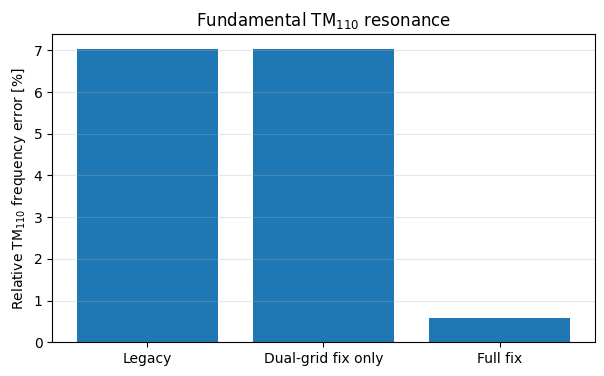

In [32]:
search_half_width = 0.12e9

errors = []

print(f"Analytical TM110: {f110 / 1e9:.6f} GHz\n")

for label, data in results.items():
    frequency = data["frequency"]
    spectrum = data["spectrum"]

    mask = np.abs(frequency - f110) <= search_half_width

    local_frequency = frequency[mask]
    local_spectrum = spectrum[mask]

    peak_index = np.argmax(local_spectrum)
    numerical_frequency = local_frequency[peak_index]

    relative_error = abs(numerical_frequency - f110) / f110

    data["f110_numerical"] = numerical_frequency
    data["f110_error"] = relative_error
    errors.append(relative_error)

    print(
        f"{label:18s}: "
        f"{numerical_frequency / 1e9:.6f} GHz "
        f"({100 * relative_error:.3f} % error)"
    )

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    [case[0] for case in cases],
    100 * np.asarray(errors),
)
ax.set_ylabel(r"Relative TM$_{110}$ frequency error [%]")
ax.set_title(r"Fundamental TM$_{110}$ resonance")
ax.grid(True, axis="y", alpha=0.3)

plt.show()

## Interpretation

The legacy implementation combines zero-length dual edges at the high-side domain boundaries with explicit masking of the last stored tangential E-field layer.

Correcting only the dual-grid geometry makes the last dual edges finite, but the former PEC treatment still removes the corresponding last stored interior E-field layer.

The **full fix** combines finite dual boundary edges with the corrected high-side PEC treatment. In the rectangular-cavity test, the resulting fundamental $TM_{110}$ resonance should therefore agree most closely with the analytical value.
